# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is called linear because it is linear in the coefficients, not necessarily the variables themselves. Basically, the output is built as a weighted sum of the inputs. Even if you include things like squared terms, it is still considered linear as long as the coefficients are not multiplied together or raised to powers.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

For a dummy variable, the coefficient tells you how much that category changes the outcome compared to the baseline group. The baseline group is the one you leave out, and its effect is captured in the intercept. So every dummy coefficient is just a difference from that reference category.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can technically be used for classification by predicting values like zero or one, but it is not a great choice. The predictions can go below zero or above one, which does not make sense for probabilities. That is why models like logistic regression are usually used instead.

4. What are signs that your linear model is over-fitting?

A big sign of overfitting is when the model does really well on the training data but performs worse on new or test data. It can also show up when the model is overly complex or when the coefficients seem unusually large and unstable.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity means that some of the predictors are highly related to each other, which makes it hard to figure out their individual effects. With two stage least squares, you deal with this by first predicting the problematic variable using other variables that are not related to the error, and then using that predicted version in the main regression. This helps stabilize the estimates.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can handle nonlinear relationships by transforming your variables. For example, you can include squared terms, logs, or interaction terms. Even though the relationship becomes curved, the model is still linear in how the coefficients are used.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient tells you how much the outcome changes when one input increases by one unit, while holding everything else constant. It gives you the direction and size of that relationship.

8. Compare the train/test split and $k$-fold cross validation.

A train test split uses one fixed split of the data into training and testing sets, which is simple but can depend a lot on how the split is done. K fold cross validation splits the data into multiple parts and rotates which part is used for testing, so it gives a more reliable sense of how the model performs.

9. How is the $k$ in $k$-fold cross validation typically selected?

The value of k is usually chosen as five or ten. These are common because they give a good balance between accuracy and how long it takes to run.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

The average prices differ quite a bit across boroughs. Manhattan is the most expensive on average at around 183 dollars per night, while the Bronx is the least expensive at about 75 dollars. Staten Island and Brooklyn fall in between, with Queens slightly lower. In contrast, review scores are very similar across boroughs and stay around the low 90s.

The price distribution is heavily right skewed, with a long tail caused by a small number of very expensive listings. This makes it harder to compare boroughs directly. After taking the log of price, the distributions become much more symmetric and easier to interpret. In the log price plot, Manhattan is clearly shifted to the right, confirming that it has higher prices overall compared to the other boroughs.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

The regression uses dummy variables for each neighbourhood, with the Bronx omitted as the baseline category. The intercept represents the average price in the Bronx, which matches the value from the grouped table. Each coefficient shows how much more expensive another borough is relative to the Bronx. For example, Manhattan’s coefficient is about 108, meaning it is about 108 dollars more expensive than the Bronx on average. These coefficients closely match the differences in average prices from part 1, showing that the regression with dummy variables reproduces the group means as differences from the baseline.

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

The coefficient on Review Scores Rating is about 1.02, which means that a one point increase in the rating is associated with about a 1 dollar increase in price. This suggests that higher-rated listings tend to be slightly more expensive, although the effect is relatively small. The R squared value is very low, indicating that review scores alone do not explain much of the variation in prices.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

The coefficient on Review Scores Rating increases slightly from about 1.02 to about 1.08 after including neighbourhood in the model. This suggests that part of the relationship between ratings and price was influenced by differences across neighbourhoods, and controlling for location makes the effect of ratings slightly stronger. The neighbourhood coefficients remain very similar to the previous model, indicating that differences in price across boroughs are still large even after accounting for review scores. This shows that location continues to be a major factor in determining price.


5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

The model allows the effect of review scores on price to vary by neighbourhood using interaction terms. The baseline slope for the Bronx is about 0.57, and the slopes for Brooklyn and Manhattan are slightly higher, around 1.3, while Queens is slightly lower. These slopes are generally similar in magnitude, suggesting that the relationship between ratings and price is fairly consistent across most boroughs. However, Staten Island shows a very large negative slope, which likely reflects noise or a small number of observations rather than a meaningful difference. Overall, the effect of ratings on price appears relatively stable across neighbourhoods.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Cross validation was used to compare the models. The model including neighbourhood and review scores had an average mean squared error of about 21113, while the interaction model had a slightly higher error of about 21418. This indicates that the simpler model without interaction terms performs better. The results suggest that allowing the effect of review scores to vary across neighbourhoods does not improve predictive performance, which is consistent with earlier findings that the slopes were fairly similar across boroughs.

In [1]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 2.00 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Q1_clean(in).csv to Q1_clean(in).csv


In [3]:
df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

NameError: name 'df' is not defined

In [4]:
import pandas as pd

df = pd.read_csv("data/Q1_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/Q1_clean.csv'

In [5]:
df = pd.read_csv("data/Q1_clean(in).csv")

In [6]:
df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

KeyError: 'Neighbourhood'

In [7]:
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# log price
df["log_price"] = np.log(df["Price"])

# price KDE
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price Distribution by Neighbourhood")
plt.show()

# log price KDE
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("data/Q1_clean(in).csv")
df.columns = df.columns.str.strip()

FileNotFoundError: [Errno 2] No such file or directory: 'data/Q1_clean(in).csv'

In [3]:
import pandas as pd
df = pd.read_csv("data/Q1_clean(in).csv")
df.columns = df.columns.str.strip()

FileNotFoundError: [Errno 2] No such file or directory: 'data/Q1_clean(in).csv'

In [4]:
import os
os.listdir("data")

FileNotFoundError: [Errno 2] No such file or directory: 'data'

In [5]:
import os
os.listdir()

['.config', 'sample_data']

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Q1_clean.csv to Q1_clean.csv


In [7]:
import pandas as pd

df = pd.read_csv("Q1_clean.csv")
df.columns = df.columns.str.strip()

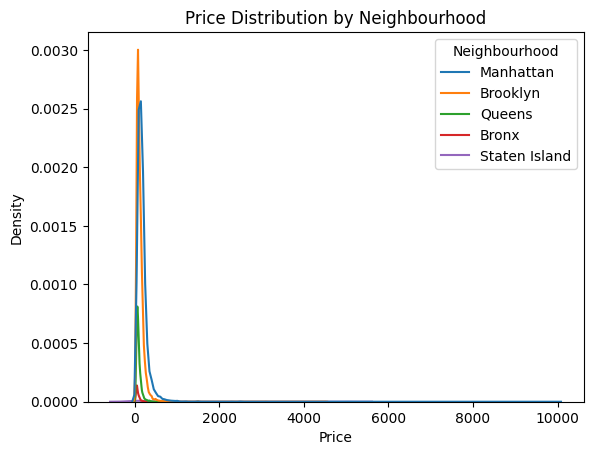

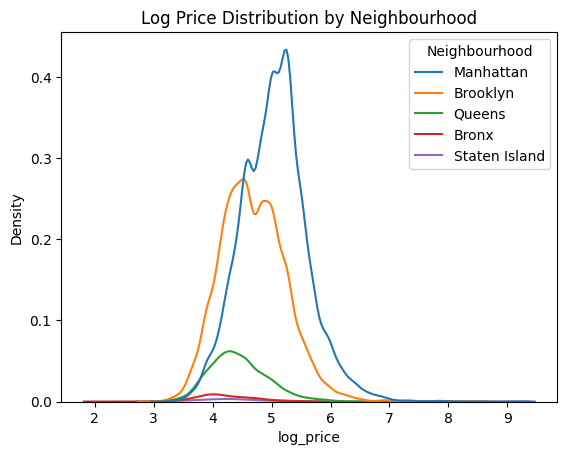

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price Distribution by Neighbourhood")
plt.show()

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

In [9]:
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

X = sm.add_constant(dummies)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

NameError: name 'sm' is not defined

In [10]:
import statsmodels.api as sm

In [11]:
import pandas as pd
import statsmodels.api as sm

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

X = sm.add_constant(dummies)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [12]:
import pandas as pd
import statsmodels.api as sm

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)

X = sm.add_constant(dummies)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        23:34:06   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [13]:
import statsmodels.api as sm

X = sm.add_constant(df["Review Scores Rating"])
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        23:34:59   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

In [14]:
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)

X = pd.concat([dummies, df["Review Scores Rating"]], axis=1)
X = sm.add_constant(X)

y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        23:36:15   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

In [15]:
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)

# interaction terms
for col in dummies.columns:
    df[f"{col}_rating"] = dummies[col] * df["Review Scores Rating"]

X = pd.concat(
    [dummies, df["Review Scores Rating"]] +
    [df[f"{col}_rating"] for col in dummies.columns],
    axis=1
)

X = sm.add_constant(X)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:37:07   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   22.6384 

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

In [17]:
# Part 4 features
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

X4 = pd.concat([dummies, df["Review Scores Rating"]], axis=1)
y = df["Price"]

model = LinearRegression()

scores4 = cross_val_score(model, X4, y, cv=5, scoring="neg_mean_squared_error")
print("Part 4 MSE:", -scores4.mean())

Part 4 MSE: 21113.112422262097


In [18]:
# interaction terms
for col in dummies.columns:
    df[f"{col}_rating"] = dummies[col] * df["Review Scores Rating"]

X5 = pd.concat(
    [dummies, df["Review Scores Rating"]] +
    [df[f"{col}_rating"] for col in dummies.columns],
    axis=1
)

scores5 = cross_val_score(model, X5, y, cv=5, scoring="neg_mean_squared_error")
print("Part 5 MSE:", -scores5.mean())

Part 5 MSE: 21418.246870450377


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

  Prices are right skewed, with most cars in the lower to mid range and a few expensive outliers. SUVs are the most expensive on average, while hatchbacks are the cheapest. SUVs also have the most variation in price, which shows up as a wider spread in the KDE plot.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

  The slope is about 59,000, meaning each additional seat increases price by roughly that amount. When treating seating capacity as categorical, the differences between groups are not evenly spaced. This shows the relationship is not perfectly linear, since some seat increases matter more than others.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

  Age was created from Make Year, and cross validation showed that a degree 5 model works best. This suggests the relationship between age and price is nonlinear rather than a straight line.

  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

  Price clearly decreases as age increases, but not in a straight line. The fitted curve captures this pattern well, showing a steeper drop for newer cars and a slower decline for older ones. It doesn’t fit every point perfectly, but it follows the overall trend pretty well.


In [19]:
import pandas as pd

df = pd.read_csv("cars_hw.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'cars_hw.csv'

In [20]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 7.82 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


<Figure size 640x480 with 0 Axes>

In [21]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw.csv to cars_hw.csv


In [22]:
import pandas as pd

df = pd.read_csv("cars_hw.csv")

In [23]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


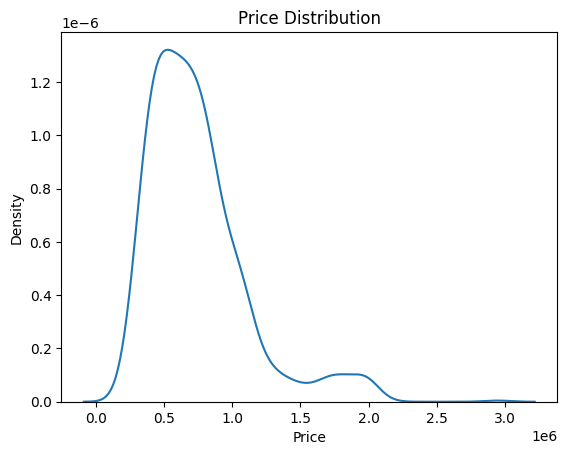

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df, x="Price")
plt.title("Price Distribution")
plt.show()

In [25]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


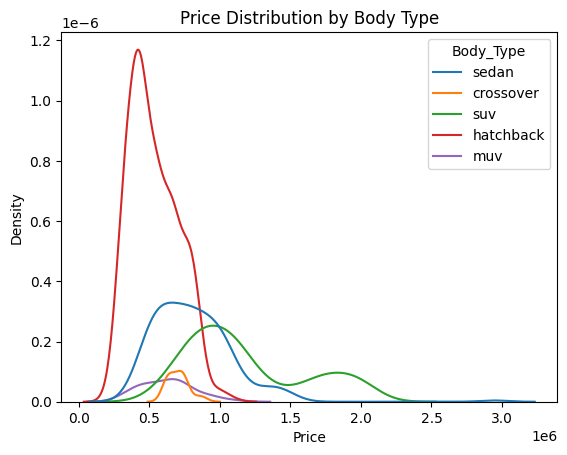

In [26]:
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.title("Price Distribution by Body Type")
plt.show()

In [27]:
import statsmodels.api as sm

X = sm.add_constant(df["Seating_Capacity"])
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        23:47:22   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [28]:
dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True)

X = sm.add_constant(dummies)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [29]:
import statsmodels.api as sm
import pandas as pd

dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True, dtype=float)

X = sm.add_constant(dummies)
y = df["Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000267
Time:                        23:48:19   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

In [30]:
df["Age"] = 2024 - df["Make_Year"]

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

y = df["Price"]

results = {}

for d in range(1, 6):  # test degrees 1 to 5
    X = pd.DataFrame()

    for i in range(1, d + 1):
        X[f"Age^{i}"] = df["Age"] ** i

    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=10, scoring="neg_mean_squared_error")

    results[d] = -scores.mean()

print(results)

{1: np.float64(100295370079.4554), 2: np.float64(100814620596.42152), 3: np.float64(100380163091.91876), 4: np.float64(100474431121.11728), 5: np.float64(100131346194.72885)}


In [33]:
best_degree = min(results, key=results.get)
print("Best degree:", best_degree)

Best degree: 5


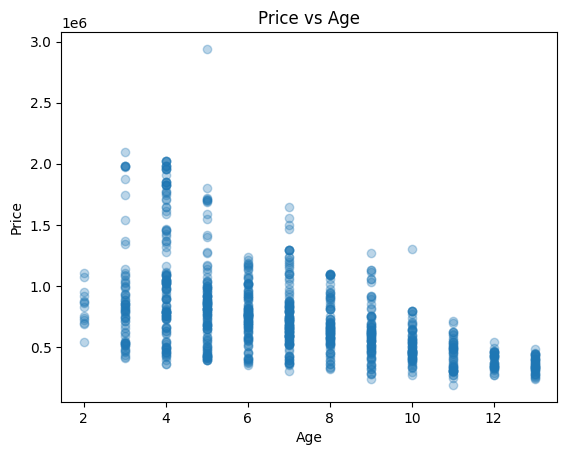

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Price"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

In [35]:
from sklearn.linear_model import LinearRegression

X = pd.DataFrame()

for i in range(1, 6):
    X[f"Age^{i}"] = df["Age"] ** i

model = LinearRegression()
model.fit(X, df["Price"])

LinearRegression()

In [36]:
df["predicted_price"] = model.predict(X)

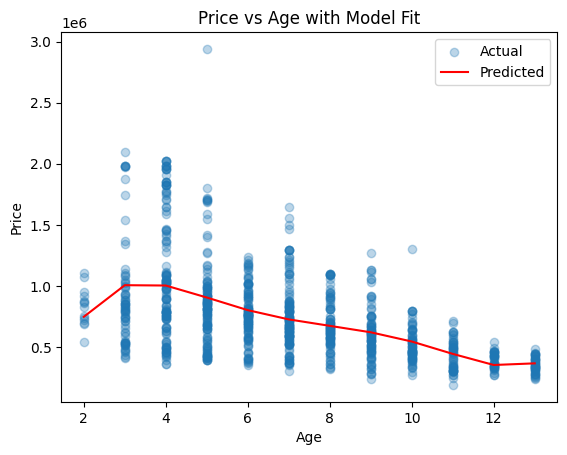

In [37]:
plt.scatter(df["Age"], df["Price"], alpha=0.3, label="Actual")

# sort for smooth line
sorted_df = df.sort_values("Age")

plt.plot(sorted_df["Age"], sorted_df["predicted_price"], color="red", label="Predicted")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Fit")
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

The survival rate in the control group is about 0.118, while the survival rate in the treatment group is about 0.348. The average treatment effect is about 0.23, meaning that receiving a transplant is associated with roughly a 23 percentage point increase in the probability of survival.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

The intercept is about 0.118, which represents the survival rate for the control group. The coefficient on transplant is about 0.23, which represents the difference in survival between the treatment and control groups. These values match the results from part 1, showing that the regression reproduces the group means and the average treatment effect.


3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

When age is included, the transplant effect increases slightly to about 0.265, suggesting age was affecting the relationship. The age coefficient is negative (about -0.0136), meaning survival decreases as age increases.

From the plot, the gap between treatment and control stays pretty similar across age, but the ATE slightly overestimates the effect for younger patients and underestimates it for older ones.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

The interaction coefficient is about -0.0146, which means the effect of a transplant decreases as age increases. The lines are no longer parallel, and the gap between treatment and control shrinks with age. This shows the benefit of a transplant depends on age and is larger for younger patients.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

Model 2 MSE is about 0.210, Model 3 is about 0.199, and Model 4 is about 0.196. Model 4 performs best, so including age and the interaction improves prediction.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

One issue is fairness. Since the model shows lower benefits for older patients, it could lead to them being deprioritized, which raises ethical concerns.

Another issue is that the model leaves out important factors like overall health, so it may not fully capture survival chances.

Also, the data is observational, so we can’t be sure the relationships are truly causal. The model should be used carefully and not as the only basis for decisions.


In [38]:
from google.colab import files
uploaded = files.upload()

Saving heart_hw.csv to heart_hw.csv


In [39]:
import pandas as pd

df = pd.read_csv("heart_hw.csv")

In [40]:
df.groupby("transplant")["y"].mean()

,y
transplant,
control,0.117647
treatment,0.347826


In [41]:
ate = (
    df[df["transplant"] == "treatment"]["y"].mean()
    - df[df["transplant"] == "control"]["y"].mean()
)

print(ate)

0.23017902813299232


In [42]:
import statsmodels.api as sm

# convert to dummy (treatment = 1)
df["transplant_dummy"] = (df["transplant"] == "treatment").astype(int)

X = sm.add_constant(df["transplant_dummy"])
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        00:04:24   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

In [43]:
X = df[["transplant_dummy", "age"]]
X = sm.add_constant(X)
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        00:05:56   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7020      0.196  

In [44]:
import numpy as np
import matplotlib.pyplot as plt

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

# predictions
control_pred = model.predict(sm.add_constant(pd.DataFrame({
    "transplant_dummy": 0,
    "age": ages
})))

treatment_pred = model.predict(sm.add_constant(pd.DataFrame({
    "transplant_dummy": 1,
    "age": ages
})))

plt.plot(ages, control_pred, label="Control")
plt.plot(ages, treatment_pred, label="Treatment")
plt.axhline(y=0.23, linestyle="--", color="gray", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.title("Survival by Age and Treatment")
plt.show()

ValueError: shapes (100,2) and (3,) not aligned: 2 (dim 1) != 3 (dim 0)

In [45]:
# control (0)
control_df = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 0,
    "age": ages
})

control_pred = model.predict(control_df)

# treatment (1)
treatment_df = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 1,
    "age": ages
})

treatment_pred = model.predict(treatment_df)

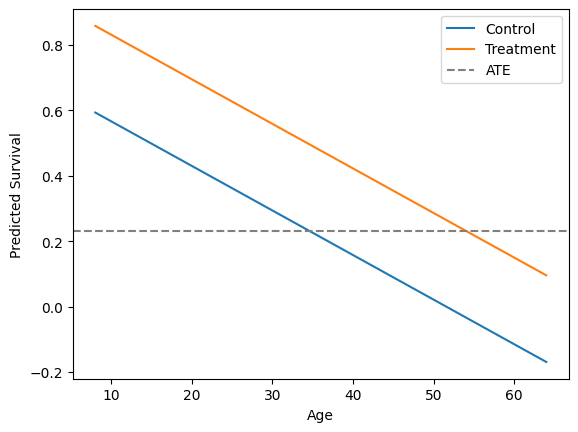

In [46]:
plt.plot(ages, control_pred, label="Control")
plt.plot(ages, treatment_pred, label="Treatment")
plt.axhline(y=0.23, linestyle="--", color="gray", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.show()

In [47]:
df["interaction"] = df["transplant_dummy"] * df["age"]

In [48]:
X = df[["transplant_dummy", "age", "interaction"]]
X = sm.add_constant(X)
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        00:09:19   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

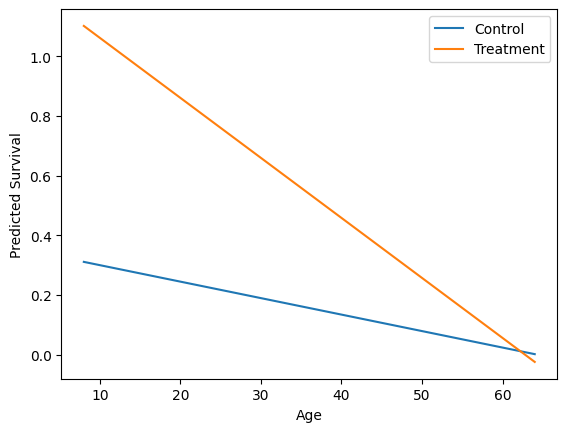

In [49]:
control_df = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 0,
    "age": ages,
    "interaction": 0
})

treatment_df = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 1,
    "age": ages,
    "interaction": ages
})

control_pred = model.predict(control_df)
treatment_pred = model.predict(treatment_df)

plt.plot(ages, control_pred, label="Control")
plt.plot(ages, treatment_pred, label="Treatment")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.show()

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

y = df["y"]
model = LinearRegression()

# Model 2
X2 = df[["transplant_dummy"]]
scores2 = cross_val_score(model, X2, y, cv=10, scoring="neg_mean_squared_error")

# Model 3
X3 = df[["transplant_dummy", "age"]]
scores3 = cross_val_score(model, X3, y, cv=10, scoring="neg_mean_squared_error")

# Model 4
X4 = df[["transplant_dummy", "age", "interaction"]]
scores4 = cross_val_score(model, X4, y, cv=10, scoring="neg_mean_squared_error")

print("Model 2 MSE:", -scores2.mean())
print("Model 3 MSE:", -scores3.mean())
print("Model 4 MSE:", -scores4.mean())

Model 2 MSE: 0.20970277289824915
Model 3 MSE: 0.19922806049232317
Model 4 MSE: 0.19609811380122735
